In [1]:
import os
import torch 
import torch.nn as nn 
from torchvision.models import resnet18, ResNet18_Weights 
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import numpy as np
from tqdm import tqdm

# preprocessing dataset to feed images and crops
class LRDDDataset(Dataset):
    def __init__(self, csv_file, img_folder, labels_folder):
        self.metadata = pd.read_csv(csv_file)
        self.imgs = img_folder
        self.yolo_labels = labels_folder
        self.transform = v2.Compose([
            v2.Resize((224,224)), 
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale = True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_name = row['img_name']
        
        img = os.path.join(self.imgs, row['img_name'])
        
        img = Image.open(img).convert('RGB')
        
        img_width,img_height = img.size
        
        label_path = os.path.join(self.yolo_labels, img_name.replace('.jpg', '.txt'))
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                line = f.readline().strip()
                if not line:
                    crop = img
                    width = height = area = aspect = 0.0
                else: 
                    line = line.split()
                    _, x_center, y_center, width, height = map(float, line)
                    #calculating the crop coordinates to get drone crops from image
                    x_center_pixels, y_center_pixels, width_pixels, height_pixels = x_center*img_width, y_center*img_height, width*img_width, height*img_height 
                    
                    x_min, y_min, x_max, y_max = x_center_pixels-width_pixels/2, y_center_pixels-height_pixels/2, x_center_pixels+width_pixels/2, y_center_pixels+height_pixels/2
                    
                    crop = img.crop((x_min, y_min, x_max, y_max))
                    
                    # calculating bounding box features: 
                    area = width * height
                    aspect = width/(height + 1e-6)
        else: 
            crop = img
            width = height = area = aspect = 0.0
        
        img_tensor = self.transform(img)
        crop_tensor = self.transform(crop)
        distance = torch.tensor(row['distance_3d_ft'], dtype=torch.float32)
        bbox_features = torch.tensor([width, height, area, aspect], dtype=torch.float32)
        
        return img_tensor, crop_tensor, bbox_features, distance


Dataset length: 259


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.5702837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3328106].


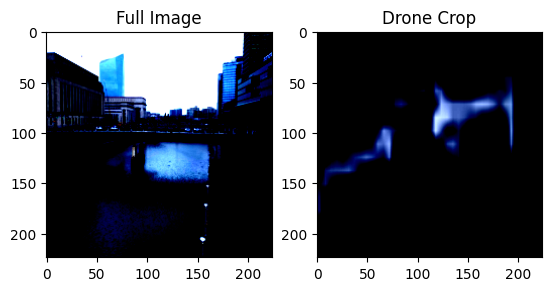

In [2]:
dataset = LRDDDataset(
    csv_file = r"F:\Projects\Distance Estimation\Current\04-11-2025_DJI_0010_metadata.csv",
    img_folder = r"F:\Projects\Distance Estimation\Current\DJI_0010\images",
    labels_folder = r"F:\Projects\Distance Estimation\Current\DJI_0010\labels"
)

print("Dataset length:", len(dataset))

# Try a sample
img, crop, bbox, dist= dataset[100]

# Visualize to confirm
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))  # convert back to HWC
plt.title(f"Full Image")
plt.subplot(1,2,2)
plt.imshow(crop.permute(1,2,0))
plt.title(f"Drone Crop")
plt.show()

In [3]:
loader = DataLoader(dataset, batch_size=8, shuffle=False)

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# disabling top layer
model.fc = nn.Identity()

for p in model.parameters():
    p.requires_grad = False

model.eval()
model.cuda()

# acquiring feature embeddings for images and crops
image_embeddings = []
crop_embeddings = []
bbox_feats = []
distances = []

with torch.no_grad(): 
    for imgs, crops, bboxf, dists in tqdm(loader):
        
        imgs = imgs.cuda()
        crops = crops.cuda()
        
        # accumulating embeddings from our model
        image_features = model(imgs)
        crop_features = model(crops)
        
        image_embeddings.append(image_features.cpu().numpy())
        crop_embeddings.append(crop_features.cpu().numpy())
        
        # accumulating bbox features and distance labels
        bbox_feats.append(bboxf.numpy())
        distances.append(dists.numpy())
        
image_embeddings = np.vstack(image_embeddings)
crop_embeddings = np.vstack(crop_embeddings)
bbox_feats = np.vstack(bbox_feats)
distances = np.concatenate(distances)

print("Embeddings shape:", image_embeddings.shape)
print("Crop Embeddings shape", crop_embeddings.shape)
print("Bounding Box Feautures", bbox_feats.shape)
print("Distances shape:", distances.shape)
        

100%|██████████| 33/33 [00:04<00:00,  7.13it/s]

Embeddings shape: (259, 512)
Crop Embeddings shape (259, 512)
Bounding Box Feautures (259, 4)
Distances shape: (259,)


In [4]:
import numpy as np
# setting independent and dependent features
X = np.hstack([image_embeddings, crop_embeddings, bbox_feats]).astype(np.float32)

y = distances.astype(np.float32).reshape(-1,1)
X.shape
X.dtype
y.shape

y_continuous = y.copy()


In [6]:
import numpy as np

# y already defined as distances.astype(np.float32).reshape(-1, 1)
y = y.ravel()

# ---- Step 1: Get the range of distances for this folder ----
y_min, y_max = float(np.min(y)), float(np.max(y))

# ---- Step 2: Round min and max to nearest multiple of 10 ----
bin_step = 10
y_min_aligned = np.floor(y_min / bin_step) * bin_step
y_max_aligned = np.ceil(y_max / bin_step) * bin_step

# ---- Step 3: Create bins dynamically ----
bin_edges = np.arange(y_min_aligned, y_max_aligned + bin_step, bin_step)

# ---- Step 4: Digitize into bins ----
y_classes = np.digitize(y, bins=bin_edges, right=False) - 1
y_classes = np.clip(y_classes, 0, len(bin_edges) - 2).astype(np.int64)

# ---- Step 5: Log ----
print(f"Distance range: {int(y_min_aligned)}–{int(y_max_aligned)} ft")
print(f"Bin edges: {bin_edges.astype(int)}")
print(f"Number of bins: {y_classes.max() + 1}")
print(f"Class index range: {y_classes.min()}–{y_classes.max()}")



Distance range: 20–100 ft
Bin edges: [ 20  30  40  50  60  70  80  90 100]
Number of bins: 8
Class index range: 0–7


In [ ]:
from torch.utils.data import TensorDataset, DataLoader 
from sklearn.model_selection import train_test_split

# perform train-test split with stratification directly on class labels
X_train, X_test, y_train_cls, y_test_cls, y_train_cont, y_test_cont = train_test_split(
    X, y_classes, y_continuous, test_size=0.3, random_state=42, stratify=y_classes
)

# convert splits into tensors
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor  = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train_cls).long()
y_test_tensor  = torch.from_numpy(y_test_cls).long()

# create TensorDatasets
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data  = TensorDataset(X_test_tensor, y_test_tensor)

# define DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"batches (train): {len(train_loader)}, batches (val): {len(test_loader)}")

batches (train): 3, batches (val): 1


In [8]:
X_train_tensor.shape

torch.Size([181, 1028])

In [ ]:
num_bins = y_classes.max() + 1
input_dim = X_train_tensor.shape[1]

classifier = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Dropout(0.3), 
    nn.Linear(128, num_bins)
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classifier = classifier.to(device)

loss_type = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(classifier.parameters(), lr = 1e-3, weight_decay = 1e-4)

In [ ]:
import torch
import torch.nn as nn
import numpy as np


# Evaluation for classification

def evaluate_classification(model, loader, device):
    """Evaluate accuracy over a DataLoader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = correct / total
    return accuracy



# Training loop for classification
def train_classifier(model, train_loader, test_loader, loss_fn, optimizer, device,
                     epochs=30, patience=5, checkpoint_path="best_classifier.pt"):
    """
    Train a classifier with early stopping based on validation accuracy.
    """
    best_acc = 0.0
    bad_epochs = 0
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device).long().squeeze()
            optimizer.zero_grad()
            logits = model(X)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        val_acc = evaluate_classification(model, test_loader, device)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

        # Early stopping check
        if val_acc > best_acc + 1e-4:
            best_acc = val_acc
            bad_epochs = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    print(f"Best Validation Accuracy: {best_acc*100:.2f}%")
    return history

history = train_classifier(classifier, train_loader, test_loader,
                           loss_type, optimizer, device)



Epoch 01 | Train Loss: 1.9496 | Val Acc: 37.18%
Epoch 02 | Train Loss: 1.6229 | Val Acc: 53.85%
Epoch 03 | Train Loss: 1.4816 | Val Acc: 56.41%
Epoch 04 | Train Loss: 1.3388 | Val Acc: 60.26%
Epoch 05 | Train Loss: 1.2633 | Val Acc: 60.26%
Epoch 06 | Train Loss: 1.1599 | Val Acc: 64.10%
Epoch 07 | Train Loss: 1.0734 | Val Acc: 67.95%
Epoch 08 | Train Loss: 1.0381 | Val Acc: 66.67%
Epoch 09 | Train Loss: 0.9956 | Val Acc: 67.95%
Epoch 10 | Train Loss: 0.8973 | Val Acc: 66.67%
Epoch 11 | Train Loss: 0.8634 | Val Acc: 67.95%
Epoch 12 | Train Loss: 0.8082 | Val Acc: 71.79%
Epoch 13 | Train Loss: 0.7683 | Val Acc: 73.08%
Epoch 14 | Train Loss: 0.7526 | Val Acc: 76.92%
Epoch 15 | Train Loss: 0.7040 | Val Acc: 76.92%
Epoch 16 | Train Loss: 0.6705 | Val Acc: 73.08%
Epoch 17 | Train Loss: 0.6164 | Val Acc: 76.92%
Epoch 18 | Train Loss: 0.5887 | Val Acc: 76.92%
Epoch 19 | Train Loss: 0.5933 | Val Acc: 76.92%
Early stopping triggered.
Best Validation Accuracy: 76.92%


In [12]:
classifier.eval()
all_pred_classes = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = classifier(X_batch)
        
        preds = torch.argmax(logits, dim=1)          # (batch,)
        
        all_pred_classes.append(preds.cpu().numpy())
print(logits.shape)
all_pred_classes = np.concatenate(all_pred_classes)  # shape (num_test,)
all_pred_classes


torch.Size([78, 8])


array([2, 7, 6, 1, 0, 7, 1, 7, 6, 6, 1, 2, 6, 6, 6, 7, 1, 6, 2, 6, 7, 6,
       2, 2, 6, 0, 6, 6, 1, 6, 7, 7, 6, 1, 6, 2, 2, 6, 6, 0, 7, 2, 6, 0,
       6, 6, 0, 7, 2, 7, 6, 6, 6, 7, 0, 6, 1, 2, 6, 6, 6, 6, 6, 2, 6, 7,
       6, 6, 6, 6, 6, 2, 2, 7, 2, 7, 6, 6])

In [13]:
# bin_edges you already created earlier for this folder
bin_lefts  = bin_edges[all_pred_classes]
bin_rights = bin_edges[all_pred_classes + 1]
range = list((float(a),float(b)) for a, b in zip(bin_lefts,bin_rights))
print(range[:10])
pred_distances_feet = 0.5 * (bin_lefts + bin_rights)   # center of each bin
print(pred_distances_feet)


[(40.0, 50.0), (90.0, 100.0), (80.0, 90.0), (30.0, 40.0), (20.0, 30.0), (90.0, 100.0), (30.0, 40.0), (90.0, 100.0), (80.0, 90.0), (80.0, 90.0)]
[45. 95. 85. 35. 25. 95. 35. 95. 85. 85. 35. 45. 85. 85. 85. 95. 35. 85.
 45. 85. 95. 85. 45. 45. 85. 25. 85. 85. 35. 85. 95. 95. 85. 35. 85. 45.
 45. 85. 85. 25. 95. 45. 85. 25. 85. 85. 25. 95. 45. 95. 85. 85. 85. 95.
 25. 85. 35. 45. 85. 85. 85. 85. 85. 45. 85. 95. 85. 85. 85. 85. 85. 45.
 45. 95. 45. 95. 85. 85.]


In [15]:
y_true_feet = y_test_cont  # numpy array, same ordering

abs_err = np.abs(pred_distances_feet - y_true_feet)

mae  = abs_err.mean()
rmse = np.sqrt((abs_err ** 2).mean())

pct_within_10  = (abs_err <= 10).mean() * 100.0
pct_within_20  = (abs_err <= 20).mean() * 100.0

print("--------- distance quality ---------")
print(f"MAE (ft):        {mae:.2f}")
print(f"RMSE (ft):       {rmse:.2f}")
print(f"% within 10 ft:  {pct_within_10:.2f}%")
print(f"% within 20 ft:  {pct_within_20:.2f}%")
print("-------------------------------------")


--------- distance quality ---------
MAE (ft):        26.73
RMSE (ft):       34.99
% within 10 ft:  41.26%
% within 20 ft:  50.62%
-------------------------------------
